In [1]:
# Prodcut Line Profitability & Margin Performance Analysis
### Nassau Candy Distributor

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df = pd.read_csv(r"C:\Users\swathikanike\Downloads\nassau-candy-profitability-analysis\Nassau Candy Distributor dataset.csv")

In [3]:
df.head()

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Country/Region,City,State/Province,Postal Code,Division,Region,Product ID,Product Name,Sales,Units,Gross Profit,Cost
0,1,US-2021-103800-CHO-MIL-31000,03-01-2024,30-06-2026,Standard Class,103800,United States,Houston,Texas,77095,Chocolate,Interior,CHO-MIL-31000,Wonka Bar - Milk Chocolate,6.50,2,4.22,2.28
1,2,US-2021-112326-CHO-TRI-54000,04-01-2024,01-07-2026,Standard Class,112326,United States,Naperville,Illinois,60540,Chocolate,Interior,CHO-TRI-54000,Wonka Bar - Triple Dazzle Caramel,7.50,2,4.90,2.60
2,3,US-2021-112326-CHO-NUT-13000,04-01-2024,01-07-2026,Standard Class,112326,United States,Naperville,Illinois,60540,Chocolate,Interior,CHO-NUT-13000,Wonka Bar - Nutty Crunch Surprise,10.47,3,7.47,3.00
3,4,US-2021-112326-CHO-SCR-58000,04-01-2024,01-07-2026,Standard Class,112326,United States,Naperville,Illinois,60540,Chocolate,Interior,CHO-SCR-58000,Wonka Bar -Scrumdiddlyumptious,10.80,3,7.50,3.30
4,5,US-2021-141817-CHO-TRI-54000,05-01-2024,05-07-2026,Standard Class,141817,United States,Philadelphia,Pennsylvania,19143,Chocolate,Atlantic,CHO-TRI-54000,Wonka Bar - Triple Dazzle Caramel,11.25,3,7.35,3.90


In [4]:
df.shape

(10194, 18)

In [5]:
df.columns

Index(['Row ID', 'Order ID', 'Order Date', 'Ship Date', 'Ship Mode',
       'Customer ID', 'Country/Region', 'City', 'State/Province',
       'Postal Code', 'Division', 'Region', 'Product ID', 'Product Name',
       'Sales', 'Units', 'Gross Profit', 'Cost'],
      dtype='object')

In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10194 entries, 0 to 10193
Data columns (total 18 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Row ID          10194 non-null  int64  
 1   Order ID        10194 non-null  object 
 2   Order Date      10194 non-null  object 
 3   Ship Date       10194 non-null  object 
 4   Ship Mode       10194 non-null  object 
 5   Customer ID     10194 non-null  int64  
 6   Country/Region  10194 non-null  object 
 7   City            10194 non-null  object 
 8   State/Province  10194 non-null  object 
 9   Postal Code     10194 non-null  object 
 10  Division        10194 non-null  object 
 11  Region          10194 non-null  object 
 12  Product ID      10194 non-null  object 
 13  Product Name    10194 non-null  object 
 14  Sales           10194 non-null  float64
 15  Units           10194 non-null  int64  
 16  Gross Profit    10194 non-null  float64
 17  Cost            10194 non-null 

In [7]:
df.describe()

,Row ID,Customer ID,Sales,Units,Gross Profit,Cost
count,10194.000000,10194.000000,10194.000000,10194.000000,10194.000000,10194.000000
mean,5097.500000,134468.961154,13.908537,3.791838,9.166451,4.742087
std,2942.898656,20231.483007,11.341020,2.228317,6.643740,5.061647
min,1.000000,100006.000000,1.250000,1.000000,0.250000,0.600000
25%,2549.250000,117212.000000,7.200000,2.000000,4.900000,2.400000
50%,5097.500000,133550.000000,10.800000,3.000000,7.470000,3.600000
75%,7645.750000,152051.000000,18.000000,5.000000,12.250000,5.700000
max,10194.000000,192314.000000,260.000000,14.000000,130.000000,130.000000


In [8]:
df.isnull().sum()

Row ID            0
Order ID          0
Order Date        0
Ship Date         0
Ship Mode         0
Customer ID       0
Country/Region    0
City              0
State/Province    0
Postal Code       0
Division          0
Region            0
Product ID        0
Product Name      0
Sales             0
Units             0
Gross Profit      0
Cost              0
dtype: int64

In [9]:
df.duplicated().sum()

np.int64(0)

In [10]:
df["Order Date"] = pd.to_datetime(df["Order Date"], dayfirst= True)


In [11]:
df["Ship Date"] = pd.to_datetime(df["Ship Date"], dayfirst=True)

In [12]:
# create profitability metrics - gross margin%
df["Gross Margin %"] = df["Gross Profit"] / df["Sales"]

In [14]:
# profit per unit
df["Profit per Unit"] = df["Gross Profit"] / df["Units"]

In [15]:
# revenuce contribution
df["Revenue Contribution"] = df["Sales"] / df["Sales"].sum()

In [16]:
# profit contribution
df["Profit Contribution"] = df["Gross Profit"] / df["Gross Profit"].sum()

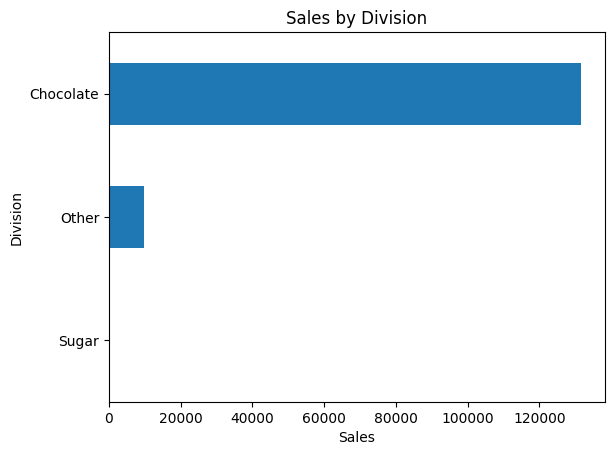

In [17]:
# sales by division
division_sales = df.groupby("Division")["Sales"].sum().sort_values()

division_sales.plot(kind="barh")
plt.title("Sales by Division")
plt.xlabel("Sales")
plt.show()

In [18]:
df.to_csv("cleaned_nassau_sales.csv", index=False)

## Product level Profitability Analysis
This section analyzes prodcut performance based on revenue, profit contribution, and margin efficiency to identify high-performing and underperforming products.

In [19]:
# Group data by product
product_analysis = df.groupby("Product Name").agg({
    "Sales" : "sum",
    "Gross Profit" : "sum",
    "Units" : "sum"
}).reset_index()

product_analysis.head()

,Product Name,Sales,Gross Profit,Units
0,Everlasting Gobstopper,130.00,104.00,13
1,Fizzy Lifting Drinks,78.75,47.25,21
2,Fun Dip,12.00,4.80,8
3,Hair Toffee,76.50,59.50,17
4,Kazookles,1205.75,92.75,371


In [20]:
product_analysis["Margin %"] = product_analysis["Gross Profit"] / product_analysis["Sales"]

product_analysis["Profit per Unit"] = product_analysis["Gross Profit"]/ product_analysis["Units"]

product_analysis.head()

,Product Name,Sales,Gross Profit,Units,Margin %,Profit per Unit
0,Everlasting Gobstopper,130.00,104.00,13,0.800000,8.00
1,Fizzy Lifting Drinks,78.75,47.25,21,0.600000,2.25
2,Fun Dip,12.00,4.80,8,0.400000,0.60
3,Hair Toffee,76.50,59.50,17,0.777778,3.50
4,Kazookles,1205.75,92.75,371,0.076923,0.25


In [21]:
# top 10 products by profits
top_profits_products = product_analysis.sort_values(
    "Gross Profit", ascending = False
).head(10)

top_profits_products

,Product Name,Sales,Gross Profit,Units,Margin %,Profit per Unit
13,Wonka Bar -Scrumdiddlyumptious,27874.80,19357.50,7743,0.694444,2.50
12,Wonka Bar - Triple Dazzle Caramel,28485.00,18610.20,7596,0.653333,2.45
10,Wonka Bar - Milk Chocolate,26867.75,17443.37,8267,0.649231,2.11
11,Wonka Bar - Nutty Crunch Surprise,23574.95,16819.95,6755,0.713467,2.49
9,Wonka Bar - Fudge Mallows,24890.40,16593.60,6914,0.666667,2.40
6,Lickable Wallpaper,7860.00,3930.00,393,0.500000,10.00
14,Wonka Gum,597.50,310.70,478,0.520000,0.65
0,Everlasting Gobstopper,130.00,104.00,13,0.800000,8.00
4,Kazookles,1205.75,92.75,371,0.076923,0.25
3,Hair Toffee,76.50,59.50,17,0.777778,3.50


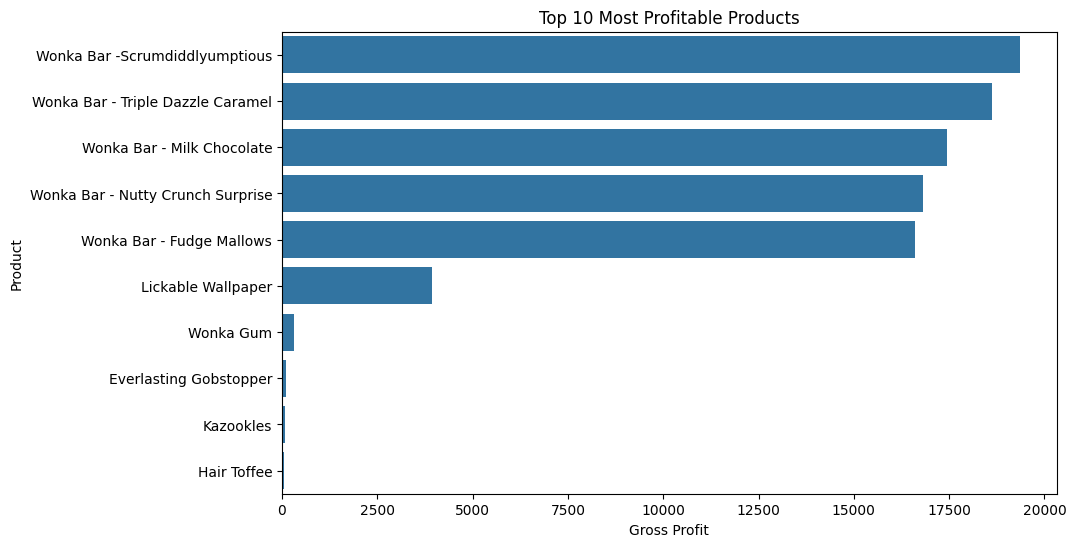

In [22]:
# barplot
plt.figure(figsize=(10,6))

sns.barplot(
    data = top_profits_products,
    x = "Gross Profit",
    y = "Product Name"
)

plt.title("Top 10 Most Profitable Products")
plt.xlabel("Gross Profit")
plt.ylabel("Product")

plt.show()

In [23]:
# highest margin products

top_margin_products = product_analysis.sort_values(
    "Margin %", ascending = False
).head(10)

top_margin_products

,Product Name,Sales,Gross Profit,Units,Margin %,Profit per Unit
0,Everlasting Gobstopper,130.00,104.00,13,0.800000,8.00
3,Hair Toffee,76.50,59.50,17,0.777778,3.50
11,Wonka Bar - Nutty Crunch Surprise,23574.95,16819.95,6755,0.713467,2.49
13,Wonka Bar -Scrumdiddlyumptious,27874.80,19357.50,7743,0.694444,2.50
9,Wonka Bar - Fudge Mallows,24890.40,16593.60,6914,0.666667,2.40
12,Wonka Bar - Triple Dazzle Caramel,28485.00,18610.20,7596,0.653333,2.45
10,Wonka Bar - Milk Chocolate,26867.75,17443.37,8267,0.649231,2.11
5,Laffy Taffy,53.73,33.48,27,0.623116,1.24
1,Fizzy Lifting Drinks,78.75,47.25,21,0.600000,2.25
14,Wonka Gum,597.50,310.70,478,0.520000,0.65


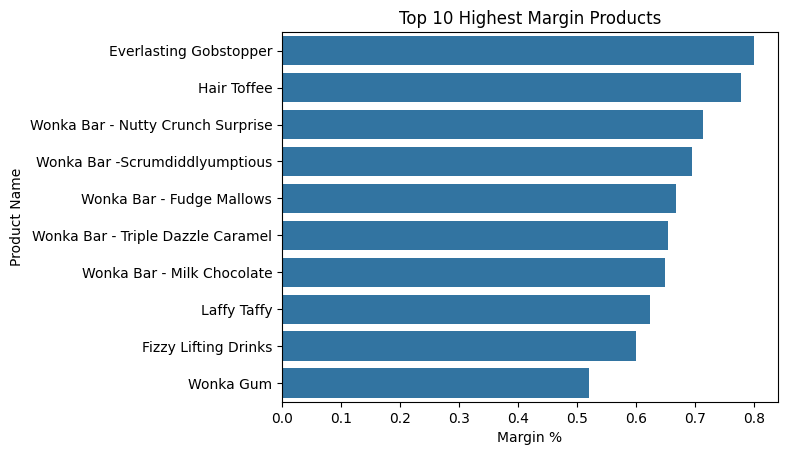

In [24]:
#barplot

plt.Figure(figsize=(10,6))

sns.barplot(
    data =  top_margin_products,
    x = "Margin %",
    y = "Product Name"
)

plt.title("Top 10 Highest Margin Products")
plt.show()

In [25]:
# high sales but low margin products

top_sales_products = product_analysis.sort_values(
    "Sales", ascending= False
).head(10)

top_sales_products

,Product Name,Sales,Gross Profit,Units,Margin %,Profit per Unit
12,Wonka Bar - Triple Dazzle Caramel,28485.00,18610.20,7596,0.653333,2.45
13,Wonka Bar -Scrumdiddlyumptious,27874.80,19357.50,7743,0.694444,2.50
10,Wonka Bar - Milk Chocolate,26867.75,17443.37,8267,0.649231,2.11
9,Wonka Bar - Fudge Mallows,24890.40,16593.60,6914,0.666667,2.40
11,Wonka Bar - Nutty Crunch Surprise,23574.95,16819.95,6755,0.713467,2.49
6,Lickable Wallpaper,7860.00,3930.00,393,0.500000,10.00
4,Kazookles,1205.75,92.75,371,0.076923,0.25
14,Wonka Gum,597.50,310.70,478,0.520000,0.65
0,Everlasting Gobstopper,130.00,104.00,13,0.800000,8.00
1,Fizzy Lifting Drinks,78.75,47.25,21,0.600000,2.25


In [26]:
# identify margin risk products
low_margin_products = product_analysis[
    product_analysis["Margin %"] < 0.20
    ]
low_margin_products.sort_values("Sales", ascending= False).head(10)

,Product Name,Sales,Gross Profit,Units,Margin %,Profit per Unit
4,Kazookles,1205.75,92.75,371,0.076923,0.25


key insights:
several Wonka Bar products generate the highest total profit, indicating strong customer demand.

kazookles product how strong sales but relatively low margin, indicating potential pricing inefficiencies.

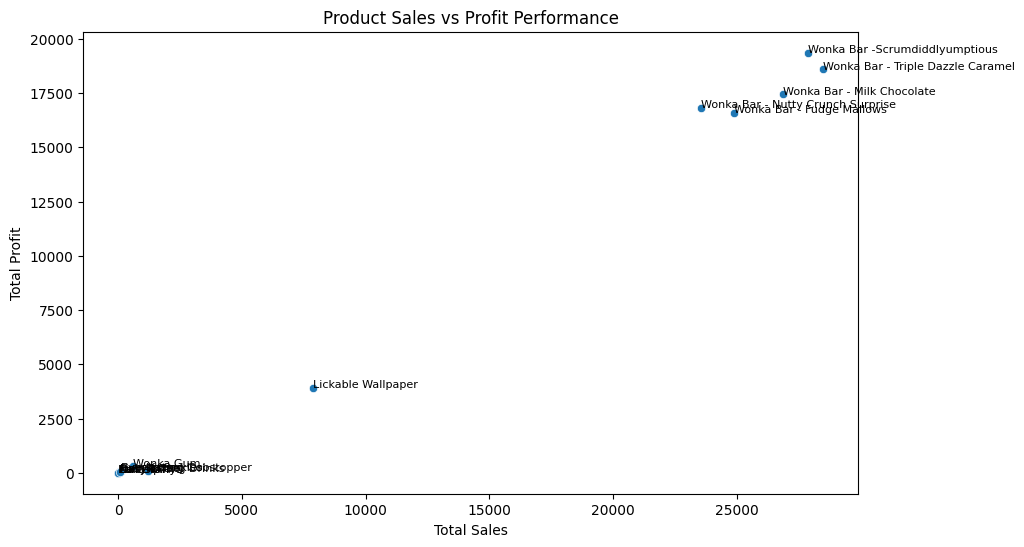

In [27]:
# sales vs profit scatter plot

plt.figure(figsize=(10,6))

sns.scatterplot(
    data = product_analysis,
    x = "Sales",
    y = "Gross Profit"
)

for i in range(len(product_analysis)):
    plt.text(
        product_analysis["Sales"][i],
        product_analysis["Gross Profit"][i],
        product_analysis["Product Name"][i],
        fontsize=8
    )

plt.title("Product Sales vs Profit Performance")
plt.xlabel("Total Sales")
plt.ylabel("Total Profit")

plt.show()

# Division Peformance Analysis

This section evaluates the financial performance of each product division based on revenue, profit contribution, and margin efficiency.

In [28]:
division_analysis = df.groupby("Division").agg({
    "Sales" : "sum",
    "Gross Profit" : "sum",
    "Units" : "sum"
}).reset_index()

division_analysis

,Division,Sales,Gross Profit,Units
0,Chocolate,131692.90,88824.62,37275
1,Other,9663.25,4333.45,1242
2,Sugar,427.48,284.73,137


In [29]:
# division margin
division_analysis["Margin %"] = (
    division_analysis["Gross Profit"] / division_analysis["Sales"]
) * 100

division_analysis

,Division,Sales,Gross Profit,Units,Margin %
0,Chocolate,131692.90,88824.62,37275,67.448298
1,Other,9663.25,4333.45,1242,44.844643
2,Sugar,427.48,284.73,137,66.606625


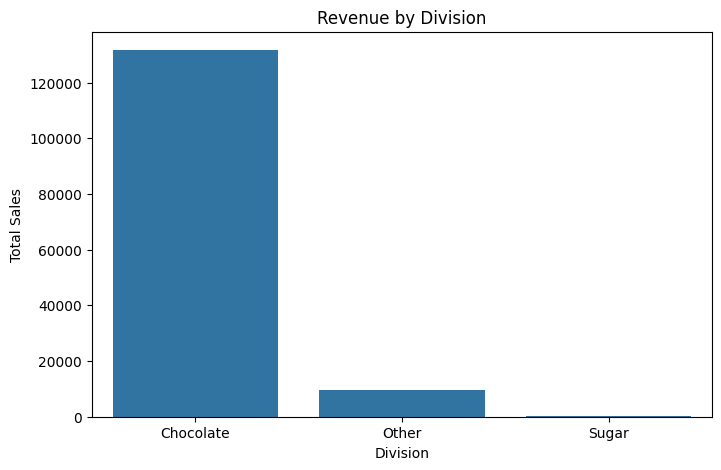

In [31]:
#revenue by division (chart)

plt.figure(figsize=(8,5))

sns.barplot(
    data = division_analysis,
    x = "Division",
    y = "Sales"
)

plt.title("Revenue by Division")
plt.xlabel("Division")
plt.ylabel("Total Sales")

plt.show()

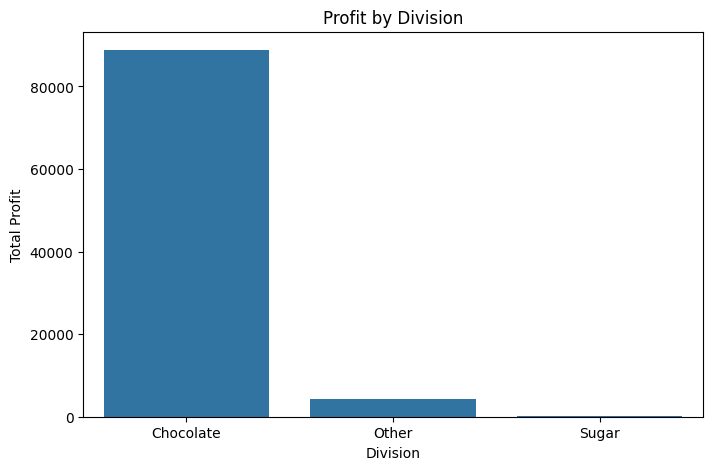

In [32]:
# profit by division

plt.figure(figsize=(8,5))

sns.barplot(
    data = division_analysis,
    x = "Division",
    y = "Gross Profit"
)

plt.title("Profit by Division")
plt.xlabel("Division")
plt.ylabel("Total Profit")

plt.show()

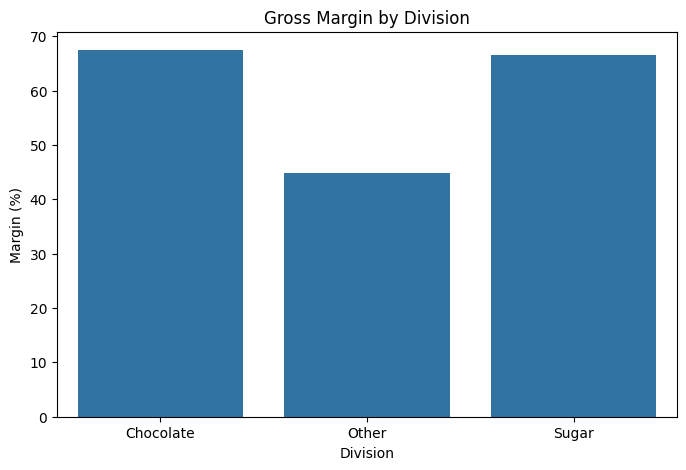

In [33]:
# margin comparison

plt.figure(figsize=(8,5))

sns.barplot(
    data = division_analysis,
    x = "Division",
    y = "Margin %"
)

plt.title("Gross Margin by Division")
plt.xlabel("Division")
plt.ylabel("Margin (%)")

plt.show()

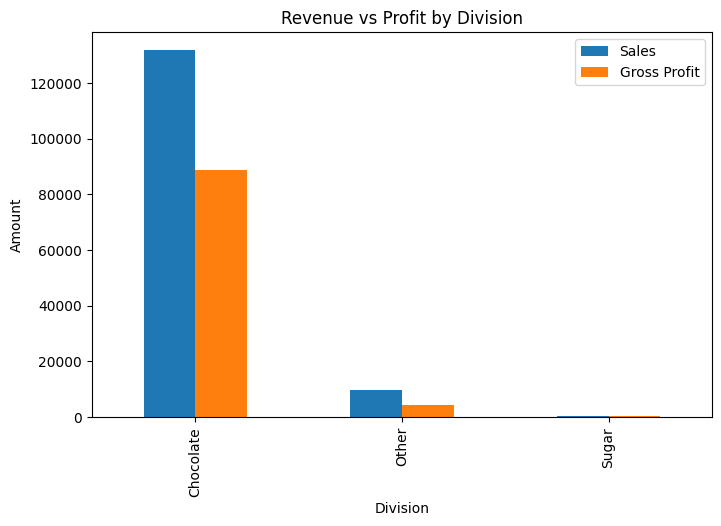

In [34]:
# revenue vs profit comparison

division_analysis_plot = division_analysis.set_index("Division")[["Sales", "Gross Profit"]]

division_analysis_plot.plot(
    kind = "bar",
    figsize=(8,5)
)

plt.title("Revenue vs Profit by Division")
plt.ylabel("Amount")

plt.show()

Insights
1. chocolate division drives the highest revenue, indicating strong customer demand for chocolate-based products.
2. The chocolate division also generate the highest total profit, confirming that it is the primary contributor to the company's financial performance.
3. In terms of margin efficiency, the chocolate division still performs well but does not significantly outperform other divisions, sales volume is high, margin are relatively low.
4. The revenue vs profit comparison shows that revenue is higher than profit across all divisions, which reflect the presence of operational and production costs.

# Pareto Analysis -  Profit Concentration

In [35]:
# sort products by profit

pareto = product_analysis.sort_values(
    "Gross Profit",
    ascending=False
).reset_index(drop=True)

pareto

,Product Name,Sales,Gross Profit,Units,Margin %,Profit per Unit
0,Wonka Bar -Scrumdiddlyumptious,27874.80,19357.50,7743,0.694444,2.50
1,Wonka Bar - Triple Dazzle Caramel,28485.00,18610.20,7596,0.653333,2.45
2,Wonka Bar - Milk Chocolate,26867.75,17443.37,8267,0.649231,2.11
3,Wonka Bar - Nutty Crunch Surprise,23574.95,16819.95,6755,0.713467,2.49
4,Wonka Bar - Fudge Mallows,24890.40,16593.60,6914,0.666667,2.40
5,Lickable Wallpaper,7860.00,3930.00,393,0.500000,10.00
6,Wonka Gum,597.50,310.70,478,0.520000,0.65
7,Everlasting Gobstopper,130.00,104.00,13,0.800000,8.00
8,Kazookles,1205.75,92.75,371,0.076923,0.25
9,Hair Toffee,76.50,59.50,17,0.777778,3.50


In [38]:
# cumulative profit
pareto["Cumulative Profit"] = pareto["Gross Profit"].cumsum()
pareto["Cumulative Profit"]

0     19357.50
1     37967.70
2     55411.07
3     72231.02
4     88824.62
5     92754.62
6     93065.32
7     93169.32
8     93262.07
9     93321.57
10    93368.82
11    93402.30
12    93431.00
13    93438.00
14    93442.80
Name: Cumulative Profit, dtype: float64

In [39]:
# cumulative profit percentage

pareto["Cumulative Profit %"] = (
    pareto["Cumulative Profit"] / 
    pareto["Gross Profit"].sum()
) * 100

pareto

,Product Name,Sales,Gross Profit,Units,Margin %,Profit per Unit,Cumulative Profit,Cumulative Profit %
0,Wonka Bar -Scrumdiddlyumptious,27874.80,19357.50,7743,0.694444,2.50,19357.50,20.715882
1,Wonka Bar - Triple Dazzle Caramel,28485.00,18610.20,7596,0.653333,2.45,37967.70,40.632023
2,Wonka Bar - Milk Chocolate,26867.75,17443.37,8267,0.649231,2.11,55411.07,59.299454
3,Wonka Bar - Nutty Crunch Surprise,23574.95,16819.95,6755,0.713467,2.49,72231.02,77.299717
4,Wonka Bar - Fudge Mallows,24890.40,16593.60,6914,0.666667,2.40,88824.62,95.057747
5,Lickable Wallpaper,7860.00,3930.00,393,0.500000,10.00,92754.62,99.263528
6,Wonka Gum,597.50,310.70,478,0.520000,0.65,93065.32,99.596031
7,Everlasting Gobstopper,130.00,104.00,13,0.800000,8.00,93169.32,99.707329
8,Kazookles,1205.75,92.75,371,0.076923,0.25,93262.07,99.806588
9,Hair Toffee,76.50,59.50,17,0.777778,3.50,93321.57,99.870263


C:\Users\swathikanike\AppData\Local\Temp\ipykernel_19196\1154303879.py:12: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax1.set_xticklabels(


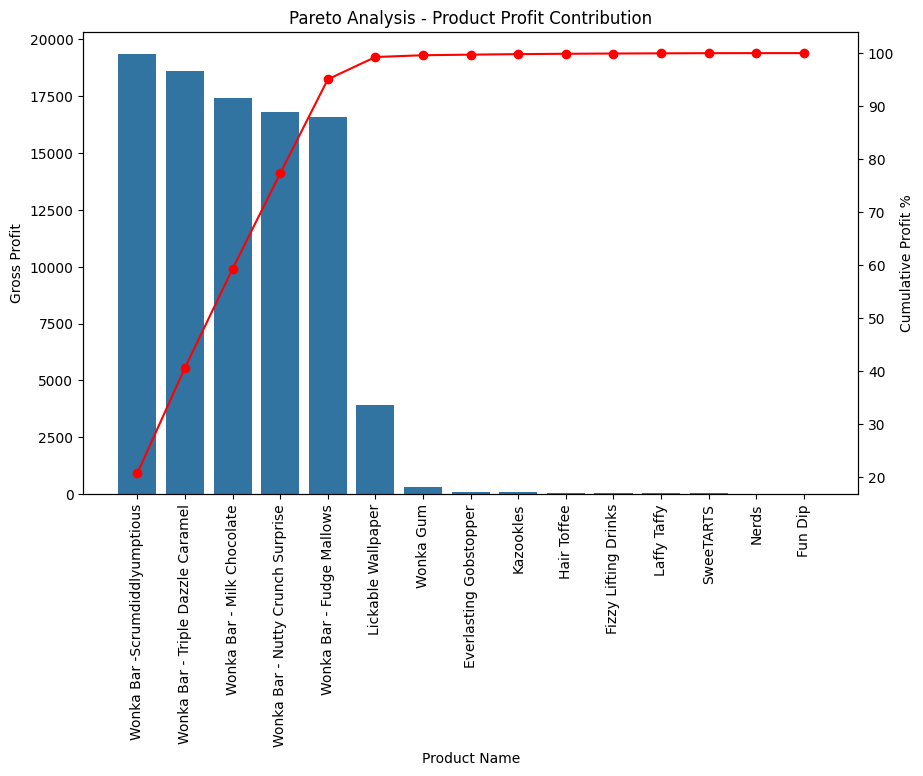

In [41]:
# pareto chart

fig, ax1 = plt.subplots(figsize=(10,6))

sns.barplot(
    data = pareto,
    x = "Product Name",
    y = "Gross Profit",
    ax = ax1
)

ax1.set_xticklabels(
    pareto["Product Name"],
    rotation = 90
)

ax2 = ax1.twinx()

ax2.plot(
    pareto["Cumulative Profit %"],
    color = "red",
    marker = "o"
)

ax2.set_ylabel("Cumulative Profit %")

plt.title("Pareto Analysis - Product Profit Contribution")

plt.show()

bars = profit per product
line =  cumulative profit %

In [42]:
# top profit drivers

pareto[["Product Name", "Gross Profit", "Cumulative Profit %"]]

,Product Name,Gross Profit,Cumulative Profit %
0,Wonka Bar -Scrumdiddlyumptious,19357.50,20.715882
1,Wonka Bar - Triple Dazzle Caramel,18610.20,40.632023
2,Wonka Bar - Milk Chocolate,17443.37,59.299454
3,Wonka Bar - Nutty Crunch Surprise,16819.95,77.299717
4,Wonka Bar - Fudge Mallows,16593.60,95.057747
5,Lickable Wallpaper,3930.00,99.263528
6,Wonka Gum,310.70,99.596031
7,Everlasting Gobstopper,104.00,99.707329
8,Kazookles,92.75,99.806588
9,Hair Toffee,59.50,99.870263


In [43]:
pareto_80 = pareto[pareto["Cumulative Profit %"] <= 80]

pareto_80.shape

(4, 8)

Pareto Analysis Insight:

The Pareto analysis reveals that profitability is highly concentrated among a small number of products.

The top 4 products account for approximately 77 % of the company's total profit, indicating a strong reliance on a few high-performing items.

This suggests that these key products should be prioritized in marketing campaigns, pricing strategies, and inventory planning to maintain strong financial performance.

# Cost Structure Diagnostics


In [45]:
cost_analysis = df.groupby("Product Name").agg({
    "Sales" : "sum",
    "Cost" : "sum",
    "Gross Profit" : "sum"
}).reset_index()

cost_analysis

,Product Name,Sales,Cost,Gross Profit
0,Everlasting Gobstopper,130.00,26.00,104.00
1,Fizzy Lifting Drinks,78.75,31.50,47.25
2,Fun Dip,12.00,7.20,4.80
3,Hair Toffee,76.50,17.00,59.50
4,Kazookles,1205.75,1113.00,92.75
5,Laffy Taffy,53.73,20.25,33.48
6,Lickable Wallpaper,7860.00,3930.00,3930.00
7,Nerds,15.00,8.00,7.00
8,SweeTARTS,61.50,32.80,28.70
9,Wonka Bar - Fudge Mallows,24890.40,8296.80,16593.60


In [46]:
# cost ratio

cost_analysis["Cost Ratio"] = cost_analysis["Cost"] / cost_analysis["Sales"]

cost_analysis

,Product Name,Sales,Cost,Gross Profit,Cost Ratio
0,Everlasting Gobstopper,130.00,26.00,104.00,0.200000
1,Fizzy Lifting Drinks,78.75,31.50,47.25,0.400000
2,Fun Dip,12.00,7.20,4.80,0.600000
3,Hair Toffee,76.50,17.00,59.50,0.222222
4,Kazookles,1205.75,1113.00,92.75,0.923077
5,Laffy Taffy,53.73,20.25,33.48,0.376884
6,Lickable Wallpaper,7860.00,3930.00,3930.00,0.500000
7,Nerds,15.00,8.00,7.00,0.533333
8,SweeTARTS,61.50,32.80,28.70,0.533333
9,Wonka Bar - Fudge Mallows,24890.40,8296.80,16593.60,0.333333


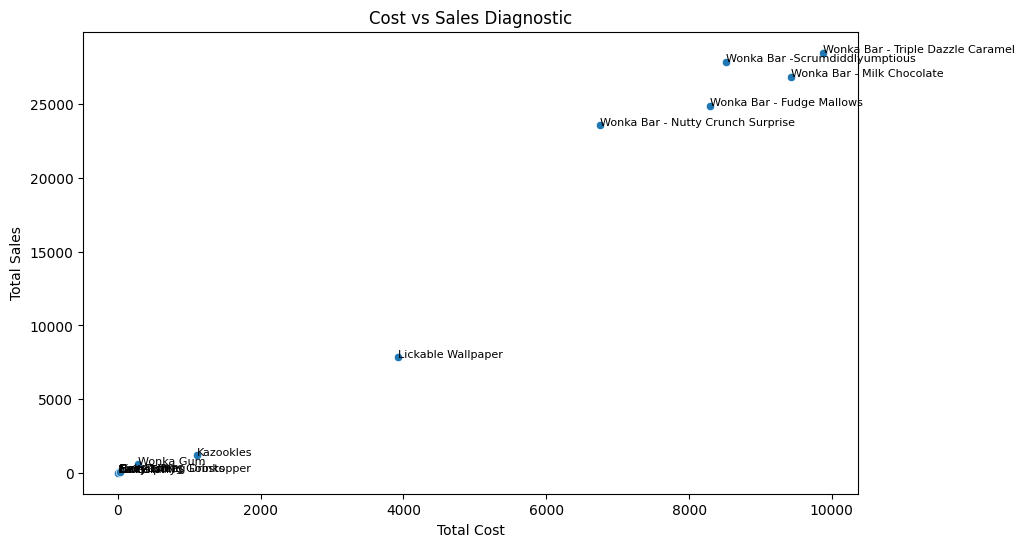

In [47]:
# cost vs sales scatter plt

plt.figure(figsize=(10,6))

sns.scatterplot(
    data = cost_analysis,
    x = "Cost",
    y = "Sales"
)

for i in range(len(cost_analysis)):
    plt.text(
        cost_analysis["Cost"][i],
        cost_analysis["Sales"][i],
        cost_analysis["Product Name"][i],
        fontsize = 8
    )

plt.title("Cost vs Sales Diagnostic")
plt.xlabel("Total Cost")
plt.ylabel("Total Sales")

plt.show()

In [48]:
# cost heavy products

cost_analysis.sort_values("Cost Ratio", ascending=False)

,Product Name,Sales,Cost,Gross Profit,Cost Ratio
4,Kazookles,1205.75,1113.00,92.75,0.923077
2,Fun Dip,12.00,7.20,4.80,0.600000
7,Nerds,15.00,8.00,7.00,0.533333
8,SweeTARTS,61.50,32.80,28.70,0.533333
6,Lickable Wallpaper,7860.00,3930.00,3930.00,0.500000
14,Wonka Gum,597.50,286.80,310.70,0.480000
1,Fizzy Lifting Drinks,78.75,31.50,47.25,0.400000
5,Laffy Taffy,53.73,20.25,33.48,0.376884
10,Wonka Bar - Milk Chocolate,26867.75,9424.38,17443.37,0.350769
12,Wonka Bar - Triple Dazzle Caramel,28485.00,9874.80,18610.20,0.346667


In [49]:
# efficient products

cost_analysis.sort_values("Cost Ratio")

,Product Name,Sales,Cost,Gross Profit,Cost Ratio
0,Everlasting Gobstopper,130.00,26.00,104.00,0.200000
3,Hair Toffee,76.50,17.00,59.50,0.222222
11,Wonka Bar - Nutty Crunch Surprise,23574.95,6755.00,16819.95,0.286533
13,Wonka Bar -Scrumdiddlyumptious,27874.80,8517.30,19357.50,0.305556
9,Wonka Bar - Fudge Mallows,24890.40,8296.80,16593.60,0.333333
12,Wonka Bar - Triple Dazzle Caramel,28485.00,9874.80,18610.20,0.346667
10,Wonka Bar - Milk Chocolate,26867.75,9424.38,17443.37,0.350769
5,Laffy Taffy,53.73,20.25,33.48,0.376884
1,Fizzy Lifting Drinks,78.75,31.50,47.25,0.400000
14,Wonka Gum,597.50,286.80,310.70,0.480000


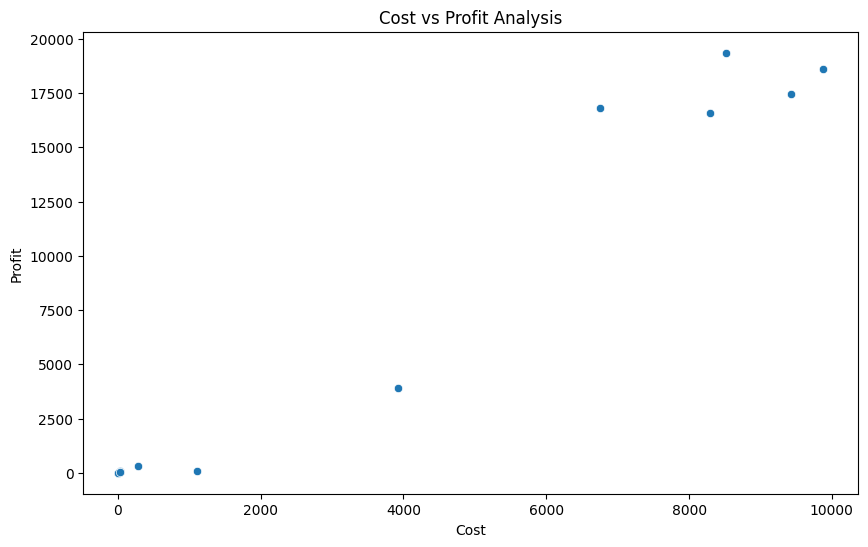

In [50]:
# cost vs profit chart

plt.figure(figsize=(10,6))

sns.scatterplot(
    data = cost_analysis,
    x = "Cost",
    y = "Gross Profit"
)

plt.title("Cost vs Profit Analysis")
plt.xlabel("Cost")
plt.ylabel("Profit")

plt.show()

Insights
The cost diagnostics reveal clear differences in cost efficiency across products.

kazookles has the highest cost ratio, indicating that a large part of its revenue is consumed by production costs.

Fun dip and Nerds also show relatively higher cost ratios.

Products such as Everlasting Gobstopper, Hair Toffee, and Wonka bar - Nutty Crunch Surprise demostrate strong cost efficiency, generating higher profit relative to their production costs.

Atlast, it suggests that Kazookles and similar products may require pricing adjustments, cost renegotiation, or operational optimization to improve profitability.

# Geographic Profitability Analysis

In [51]:
# revenue by region

region_sales = df.groupby("Region")["Sales"].sum().sort_values(ascending = False)

region_sales

Region
Pacific     46301.53
Atlantic    41197.24
Interior    32037.60
Gulf        22247.26
Name: Sales, dtype: float64

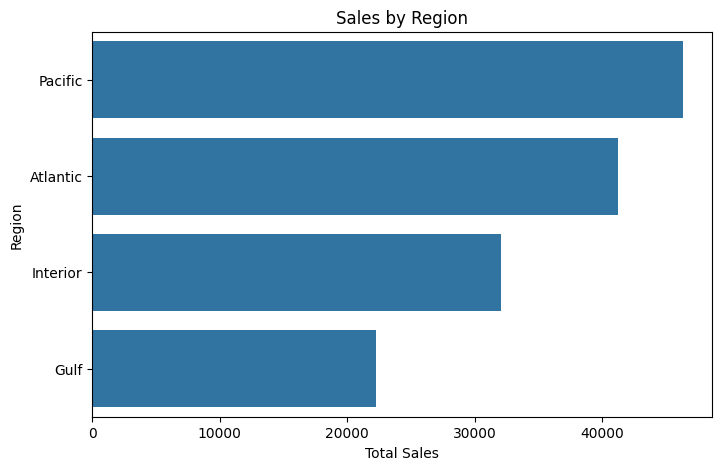

In [52]:
# plot revenue by region

plt.figure(figsize=(8,5))

sns.barplot(
    x = region_sales.values,
    y = region_sales.index
)

plt.title("Sales by Region")
plt.xlabel("Total Sales")
plt.ylabel("Region")

plt.show()

In [53]:
# profit by region

region_profit = df.groupby("Region")["Gross Profit"].sum().sort_values(ascending=False)

region_profit

Region
Pacific     30485.94
Atlantic    26973.70
Interior    21282.49
Gulf        14700.67
Name: Gross Profit, dtype: float64

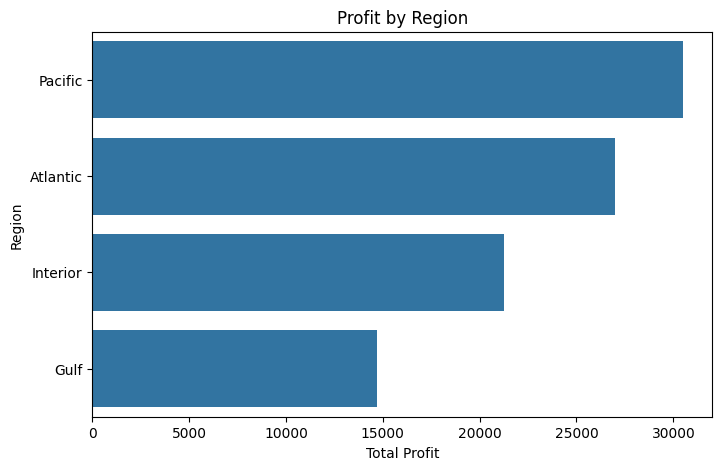

In [54]:
# barplot of profit by region
plt.figure(figsize=(8,5))

sns.barplot(
    x=region_profit.values,
    y=region_profit.index
)

plt.title("Profit by Region")
plt.xlabel("Total Profit")
plt.ylabel("Region")

plt.show()

In [58]:
state_sales = df.groupby("State/Province")["Sales"].sum().sort_values(ascending=False)

state_sales.head(10)

State/Province
California        27917.40
New York          15541.03
Texas             13416.09
Pennsylvania       8027.03
Washington         6921.15
Illinois           6898.96
Ohio               6768.95
Florida            4804.02
Arizona            3587.55
North Carolina     3450.86
Name: Sales, dtype: float64

In [59]:
# state-level profit analysis

state_profit = df.groupby("State/Province")["Gross Profit"].sum().sort_values(ascending=False)

state_profit.head(10)

State/Province
California        18479.42
New York          10222.44
Texas              8909.53
Pennsylvania       5225.47
Washington         4566.64
Illinois           4557.68
Ohio               4413.03
Florida            3207.11
North Carolina     2331.16
Arizona            2290.11
Name: Gross Profit, dtype: float64

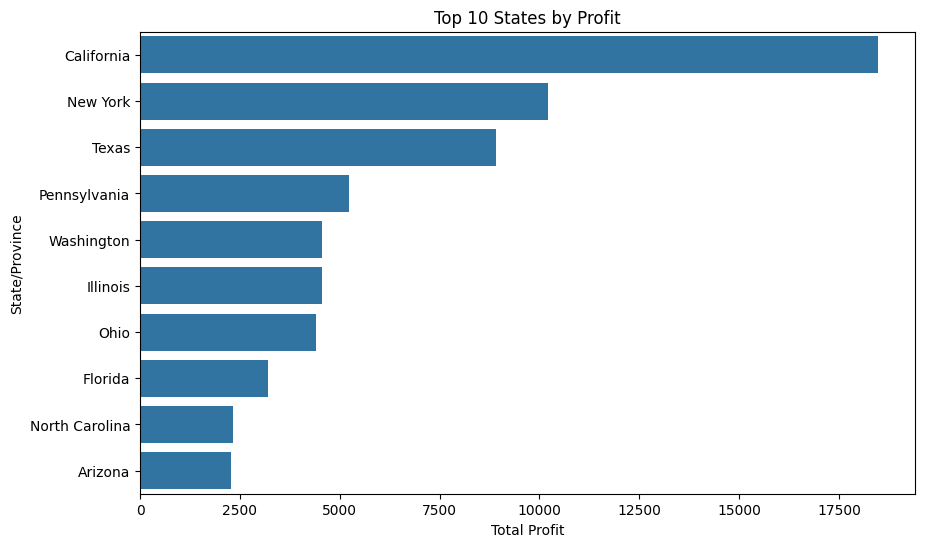

In [60]:
# barplot
plt.figure(figsize=(10,6))

sns.barplot(
    x=state_profit.head(10).values,
    y=state_profit.head(10).index
)

plt.title("Top 10 States by Profit")
plt.xlabel("Total Profit")
plt.ylabel("State/Province")

plt.show()

In [61]:
city_profit = df.groupby("City")["Gross Profit"].sum().sort_values(ascending=False)

city_profit.head(10)

City
New York City    8240.51
Los Angeles      6898.61
Philadelphia     4813.82
San Francisco    4650.77
Seattle          3880.68
Houston          3547.43
Chicago          2800.58
Columbus         2159.03
San Diego        1567.52
Springfield      1540.12
Name: Gross Profit, dtype: float64

Insights

The Pacific region generates the highest revenue and profit,
indicating strong market demand and distribution efficiency
in this region.

At the state level, California emerges as the top-performing
state in both revenue and profit, followed by New York,
Texas, and Pennsylvania. These states represent key markets
for the company's products.

City-level analysis shows that major metropolitan areas such
as New York City, Los Angeles, and Philadelphia contribute
significantly to overall profitability.

These findings suggest that the company’s strongest markets
are concentrated in large urban areas and economically
active regions. Strategic marketing and inventory allocation
should prioritize these high-performing markets while
exploring opportunities to strengthen presence in
underperforming regions.